# 02 — OEE Performance Analysis

## Objective

Analyze production performance before and after the Lean Six Sigma improvement period using:

- OEE
- Availability
- Performance
- Quality
- Production quantities
- Planned and unplanned downtime

The analysis focuses on identifying the main sources of OEE loss and evaluating whether production performance improved after LSS.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [3]:
cwd = Path.cwd()

PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
RAW_DIR = PROJECT_ROOT / "data" / "raw"

In [4]:
oee_before = pd.read_csv(RAW_DIR / "OEEdataset.csv")
oee_after = pd.read_csv(RAW_DIR / "OEEdataset_afterLSS.csv")

oee_before = (
    oee_before
    .dropna(axis=1, how="all")
    .dropna(axis=0, how="all")
    .reset_index(drop=True)
)

oee_after = (
    oee_after
    .dropna(axis=1, how="all")
    .dropna(axis=0, how="all")
    .reset_index(drop=True)
)

In [5]:
oee_before = oee_before.rename(columns={
    "shiftDate": "date",
    "Sumof goodProductionTimeSec": "good_production_time_sec",
    "Sum of slowProductionTimeSec": "slow_production_time_sec",
    "Sumof plannedTime": "planned_time_sec",
    "Sumof idealProductionQuantity": "ideal_qty",
    "Sum of plannedStopsTimeSec": "planned_stop_time_sec",
    "Sum of unplannedStopsTimeSec": "unplanned_stop_time_sec",
    "Sum of goodQty": "good_qty",
    "Sum of totalQty": "total_qty"
})

oee_after = oee_after.rename(columns={
    "shiftDate": "date",
    "Sum of goodProdction": "good_production_time_sec",
    "Sum of slowProduction": "slow_production_time_sec",
    "Sum of plannedTime": "planned_time_sec",
    "Sum of idealQty": "ideal_qty",
    "Sum of plannedStopsTimeSec": "planned_stop_time_sec",
    "Sum of unplannedStopsTimeSec": "unplanned_stop_time_sec",
    "Sum of goodQty": "good_qty",
    "Sum of totalQty": "total_qty"
})

In [6]:
oee_before["date"] = pd.to_datetime(
    oee_before["date"],
    format="%m/%d/%y"
)

oee_after["date"] = pd.to_datetime(
    oee_after["date"],
    format="%m/%d/%y"
)

oee_before["period"] = "Before LSS"
oee_after["period"] = "After LSS"

oee = pd.concat(
    [oee_before, oee_after],
    ignore_index=True
)

oee.head()

,date,OEE,Availability,Performance,Quality,good_production_time_sec,slow_production_time_sec,planned_time_sec,ideal_qty,planned_stop_time_sec,unplanned_stop_time_sec,good_qty,total_qty,period
0,2025-09-22,0.8254,0.8902,0.9272,0.9996,14604.0,1317.0,17884.0,38626.7500,13111.0,668.0,35800.0,35815.0,Before LSS
1,2025-09-23,0.5891,0.6236,0.9447,0.9975,17398.0,1123.0,29700.0,27961.0000,634.0,10545.0,26350.0,26416.0,Before LSS
2,2025-09-24,0.7498,0.7833,0.9572,0.9951,21036.0,1524.0,28800.0,22560.0000,3234.0,3006.0,21490.0,21594.0,Before LSS
3,2025-09-25,0.6546,0.7179,0.9118,0.9933,15935.0,1511.0,24300.0,18438.5334,7713.0,4541.0,16700.0,16812.0,Before LSS
4,2025-09-26,0.7397,0.8096,0.9260,0.9867,17342.0,1213.0,22920.0,25172.8000,5981.0,3364.0,23000.0,23310.0,Before LSS


In [7]:
performance_summary = (
    oee.groupby("period")
    .agg(
        days=("date", "nunique"),
        avg_oee=("OEE", "mean"),
        avg_availability=("Availability", "mean"),
        avg_performance=("Performance", "mean"),
        avg_quality=("Quality", "mean"),
        avg_unplanned_downtime_sec=("unplanned_stop_time_sec", "mean"),
        avg_good_qty=("good_qty", "mean"),
        avg_total_qty=("total_qty", "mean")
    )
    .reset_index()
)

performance_summary

,period,days,avg_oee,avg_availability,avg_performance,avg_quality,avg_unplanned_downtime_sec,avg_good_qty,avg_total_qty
0,After LSS,43,0.643029,0.697307,0.950057,0.970501,5719.000000,30224.697674,31217.000000
1,Before LSS,62,0.590697,0.643708,0.929342,0.983479,5980.677419,31070.693548,31544.048387


In [8]:
before = performance_summary.set_index("period").loc["Before LSS"]
after = performance_summary.set_index("period").loc["After LSS"]

comparison = pd.DataFrame({
    "Before LSS": before,
    "After LSS": after
})

comparison["Absolute Change"] = (
    comparison["After LSS"] - comparison["Before LSS"]
)

comparison["Relative Change (%)"] = (
    comparison["Absolute Change"] / comparison["Before LSS"] * 100
)

comparison

,Before LSS,After LSS,Absolute Change,Relative Change (%)
days,62.000000,43.000000,-19.000000,-30.645161
avg_oee,0.590697,0.643029,0.052332,8.859369
avg_availability,0.643708,0.697307,0.053599,8.326662
avg_performance,0.929342,0.950057,0.020715,2.229043
avg_quality,0.983479,0.970501,-0.012978,-1.319642
avg_unplanned_downtime_sec,5980.677419,5719.000000,-261.677419,-4.375381
avg_good_qty,31070.693548,30224.697674,-845.995874,-2.722810
avg_total_qty,31544.048387,31217.000000,-327.048387,-1.036799


In [9]:
component_comparison = pd.DataFrame({
    "Metric": ["Availability", "Performance", "Quality", "OEE"],
    "Before LSS": [
        before["avg_availability"],
        before["avg_performance"],
        before["avg_quality"],
        before["avg_oee"]
    ],
    "After LSS": [
        after["avg_availability"],
        after["avg_performance"],
        after["avg_quality"],
        after["avg_oee"]
    ]
})

component_comparison["Change (pp)"] = (
    component_comparison["After LSS"]
    - component_comparison["Before LSS"]
) * 100

component_comparison

,Metric,Before LSS,After LSS,Change (pp)
0,Availability,0.643708,0.697307,5.359939
1,Performance,0.929342,0.950057,2.071543
2,Quality,0.983479,0.970501,-1.297840
3,OEE,0.590697,0.643029,5.233201


### Initial Finding

Average OEE increased from 59.1% to 64.3% after LSS, an improvement of 5.2 percentage points.

The strongest improvement occurred in Availability, followed by Performance, while Quality declined slightly. This indicates that the OEE improvement was primarily driven by better equipment availability and operating performance rather than quality gains.

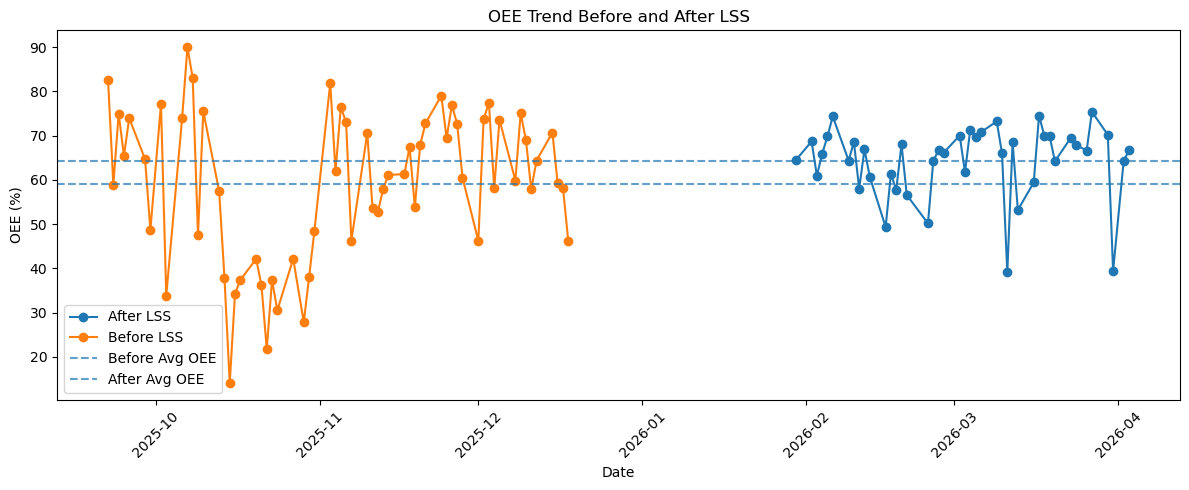

In [12]:
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 5))

for period, group in oee.groupby("period"):
    plt.plot(
        group["date"],
        group["OEE"] * 100,
        marker="o",
        label=period
    )

plt.axhline(
    before["avg_oee"] * 100,
    linestyle="--",
    alpha=0.7,
    label="Before Avg OEE"
)

plt.axhline(
    after["avg_oee"] * 100,
    linestyle="--",
    alpha=0.7,
    label="After Avg OEE"
)

plt.title("OEE Trend Before and After LSS")
plt.xlabel("Date")
plt.ylabel("OEE (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "oee_trend_before_after_lss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### OEE Trend

The post-LSS period shows a higher average OEE level than the pre-LSS period, although daily variability remains present.

The next step is to determine which OEE component contributes most to the observed performance gap.

In [11]:
oee_distribution = (
    oee.groupby("period")["OEE"]
    .agg(["mean", "median", "std", "min", "max"])
    .mul(100)
    .round(2)
)

oee_distribution

,mean,median,std,min,max
period,,,,,
After LSS,64.30,66.64,8.23,39.08,75.40
Before LSS,59.07,60.83,16.98,14.08,90.03


### OEE Performance Summary

- Average OEE increased from 59.1% before LSS to 64.3% after LSS.
- Availability showed the largest improvement (+5.4 percentage points).
- Performance improved by 2.1 percentage points.
- Quality decreased by 1.3 percentage points.
- The post-LSS period also shows fewer extreme low-OEE days.

Overall, the improvement in OEE was primarily associated with higher Availability and Performance.